## Carregando Arquivo CSV

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')


In [36]:
df = pd.read_csv("dataset/completo_normalizado_clustering.csv", sep=",")

In [37]:
df

,periodo,qtd_discentes,postura_profissional_media,postura_profissional_DP,atuacao_profissional_media,atuacao_profissional_DP,autoavaliacao_aluno_media,autoavaliacao_aluno_DP,media_final_geral,qtd_aprovado,...,classe_funcional_A,classe_funcional_Adjunto,classe_funcional_Auxiliar,classe_funcional_B,classe_funcional_C,classe_funcional_Classe A - Auxiliar,classe_funcional_D,classe_funcional_DI,classe_funcional_Não Informada,classe_funcional_Titular
0,0.0,0.035948,0.986,0.050919,0.985263,0.071138,0.941696,0.117521,0.881818,0.037801,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.055556,0.957,0.118812,0.946316,0.254065,0.803887,0.412393,0.648333,0.020619,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.029412,0.929,0.195191,0.918947,0.306911,0.780919,0.369658,0.855714,0.024055,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.045752,0.980,0.073550,0.978947,0.113821,0.846290,0.369658,0.820769,0.044674,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.019608,0.975,0.063649,0.908421,0.227642,0.798587,0.292735,1.000000,0.020619,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126289,1.0,0.114379,0.948,0.130127,0.916842,0.219512,NaN,NaN,0.854138,0.099656,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
126290,0.0,0.071895,0.946,0.145686,0.887368,0.294715,NaN,NaN,0.865789,0.065292,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
126291,0.0,0.176471,0.932,0.171146,0.874737,0.357724,NaN,NaN,0.843750,0.164948,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
126292,0.0,0.062092,0.908,0.181047,0.890526,0.219512,NaN,NaN,0.936111,0.061856,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


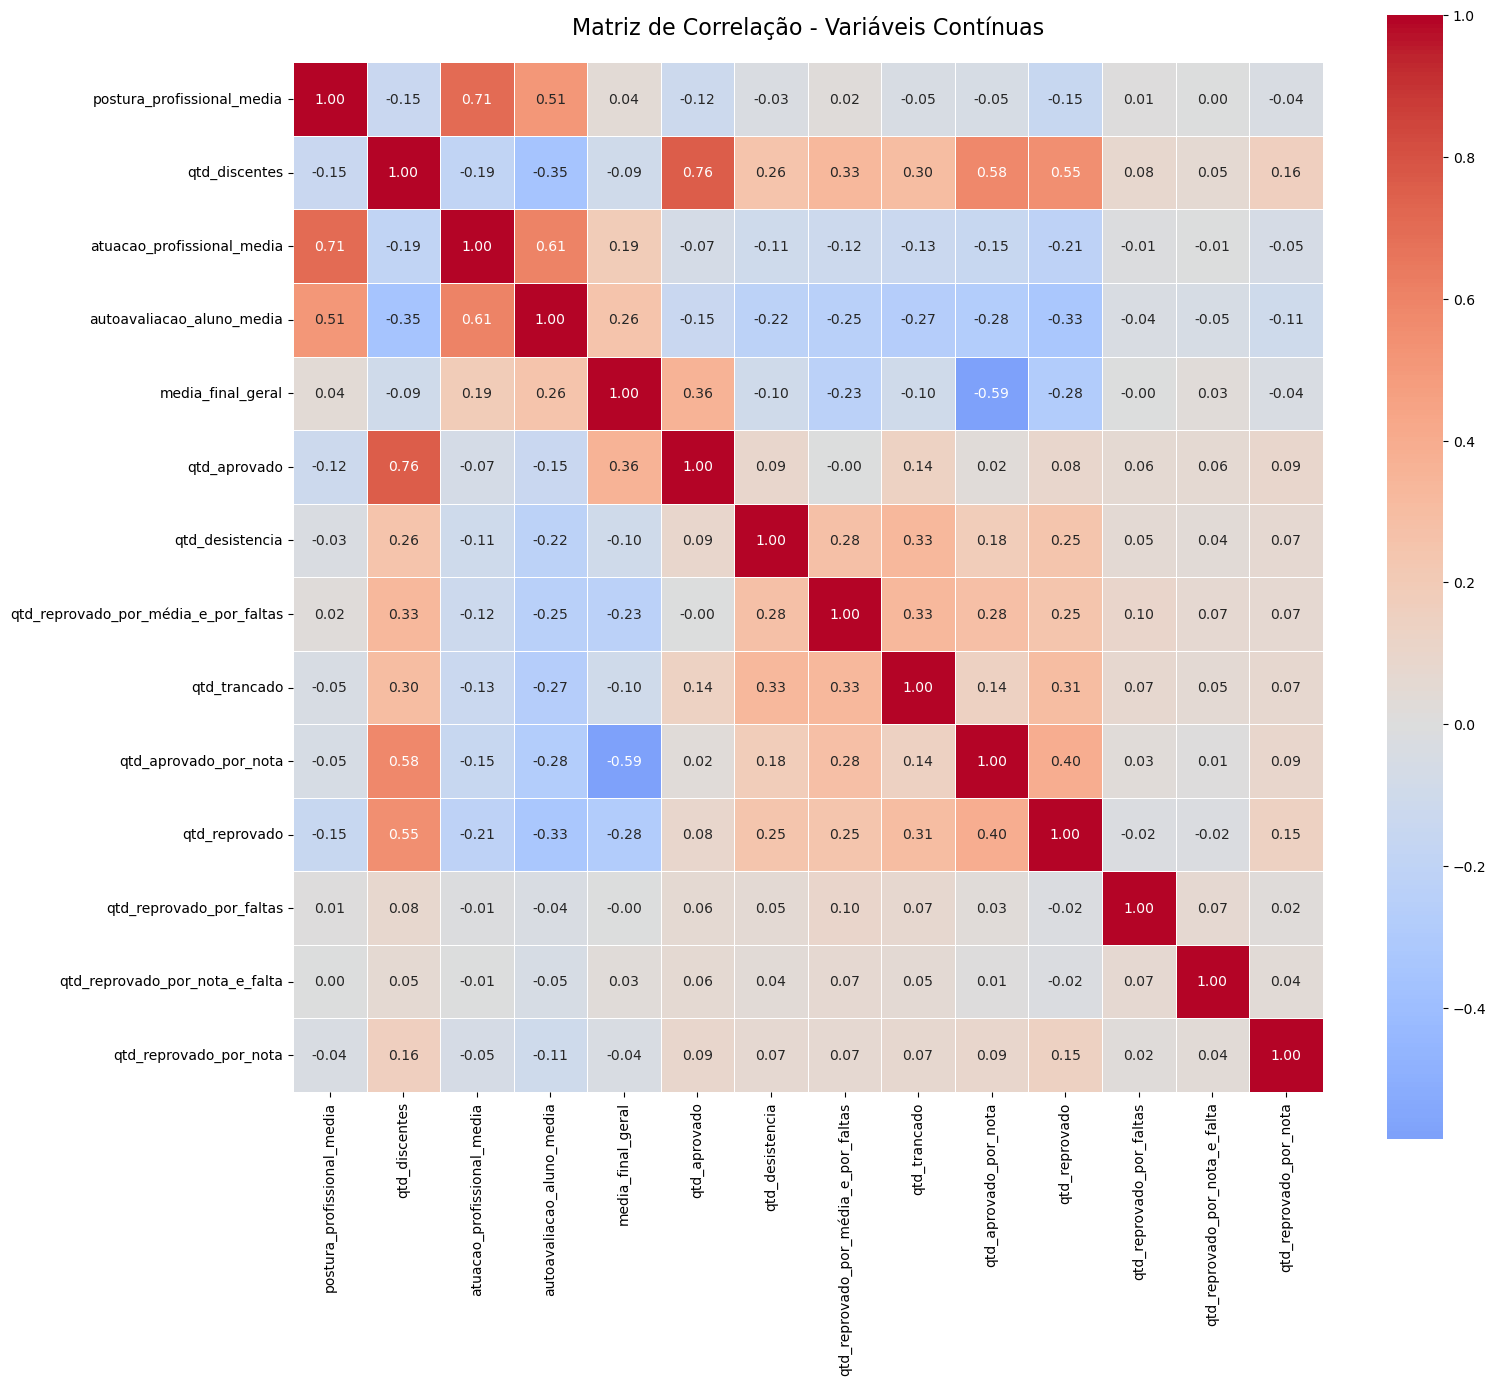

In [38]:
colunas_continuas = [
    'postura_profissional_media', 'qtd_discentes',
    'atuacao_profissional_media', 
    'autoavaliacao_aluno_media', 'media_final_geral',
    'qtd_aprovado', 'qtd_desistencia',
    'qtd_reprovado_por_média_e_por_faltas', 'qtd_trancado',
    'qtd_aprovado_por_nota', 'qtd_reprovado',
    'qtd_reprovado_por_faltas', 'qtd_reprovado_por_nota_e_falta',
    'qtd_reprovado_por_nota'
]

df_continuas = df[colunas_continuas]

df_continuas = df_continuas.dropna()

correlation_matrix = df_continuas.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Contínuas', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [39]:
features_clustering = [
    'qtd_discentes',
    'postura_profissional_media',
    'atuacao_profissional_media',
    'autoavaliacao_aluno_media',
    'media_final_geral',
    'qtd_trancado',
    'qtd_aprovado',
    'qtd_aprovado_por_nota',
    'qtd_reprovado_por_média_e_por_faltas',
    'qtd_reprovado',
    'qtd_desistencia'
]


df_cluster = df[features_clustering].copy()
df_cluster = df_cluster.dropna()


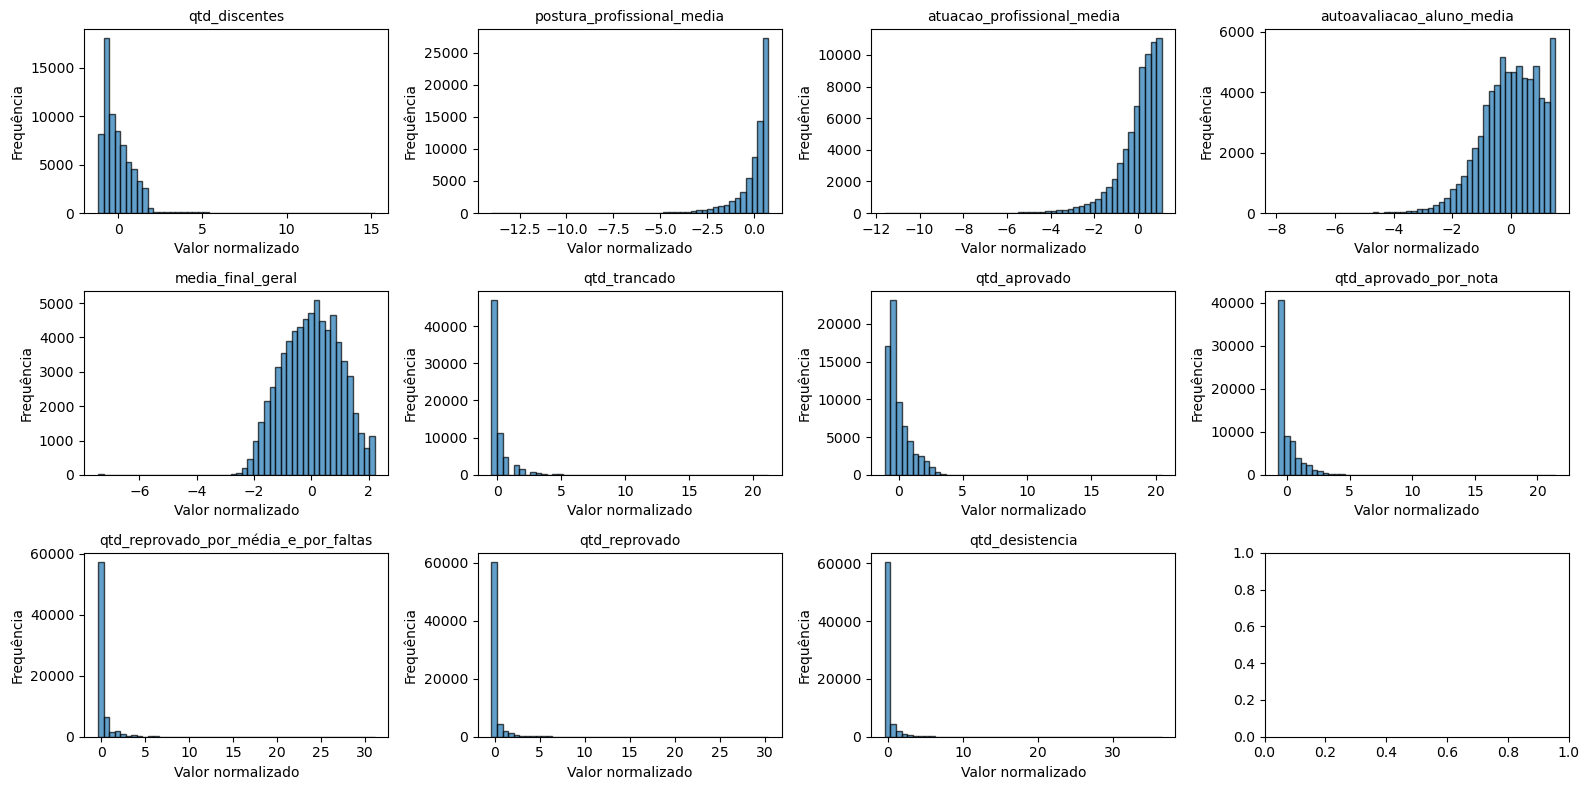

In [40]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(df_scaled, columns=features_clustering)

#visualização pós normalização
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(features_clustering):
    axes[idx].hist(df_scaled[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=10)
    axes[idx].set_xlabel('Valor normalizado')
    axes[idx].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

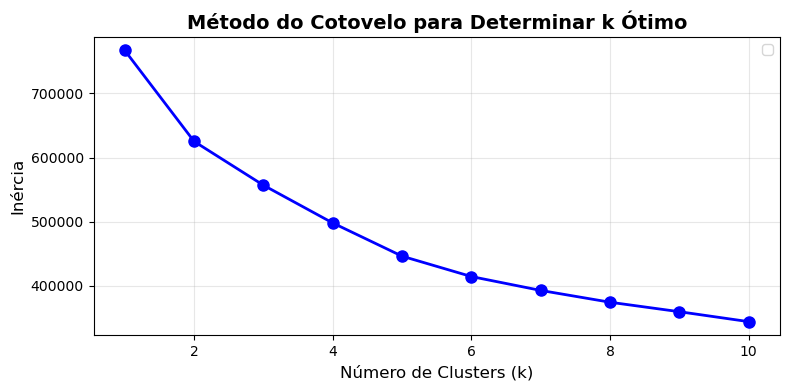

In [41]:
k_range = range(1, 11)
inertias = []


for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(df_scaled)
  inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.title('Método do Cotovelo para Determinar k Ótimo', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

#plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (Real)')
plt.legend()
plt.tight_layout()
plt.show()

k=2: Silhouette Score = 0.306
k=3: Silhouette Score = 0.258
k=4: Silhouette Score = 0.236
k=5: Silhouette Score = 0.242
k=6: Silhouette Score = 0.232
k=7: Silhouette Score = 0.237
k=8: Silhouette Score = 0.196
k=9: Silhouette Score = 0.187
k=10: Silhouette Score = 0.188

Melhor k segundo Silhueta: 2 (Score: 0.306)


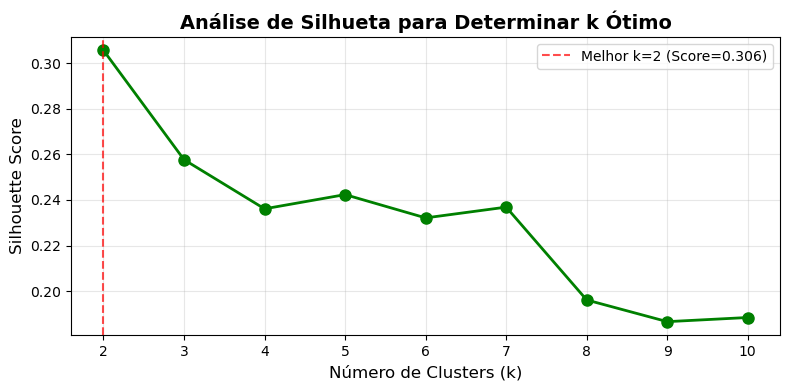

In [42]:
from sklearn.metrics import silhouette_score

# método da silhueta
k_range_silhouette = range(2, 11)
silhouette_scores = []

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.3f}")

best_k = k_range_silhouette[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"\nMelhor k segundo Silhueta: {best_k} (Score: {best_score:.3f})")

plt.figure(figsize=(8, 4))
plt.plot(k_range_silhouette, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Análise de Silhueta para Determinar k Ótimo', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Melhor k={best_k} (Score={best_score:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# KMeans com k ótimo

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans_final.fit_predict(df_scaled)

print("\nDistribuição dos clusters:")
print(df_cluster['Cluster'].value_counts())



Distribuição dos clusters:
Cluster
3    33302
1    19551
0    15479
2     1396
Name: count, dtype: int64


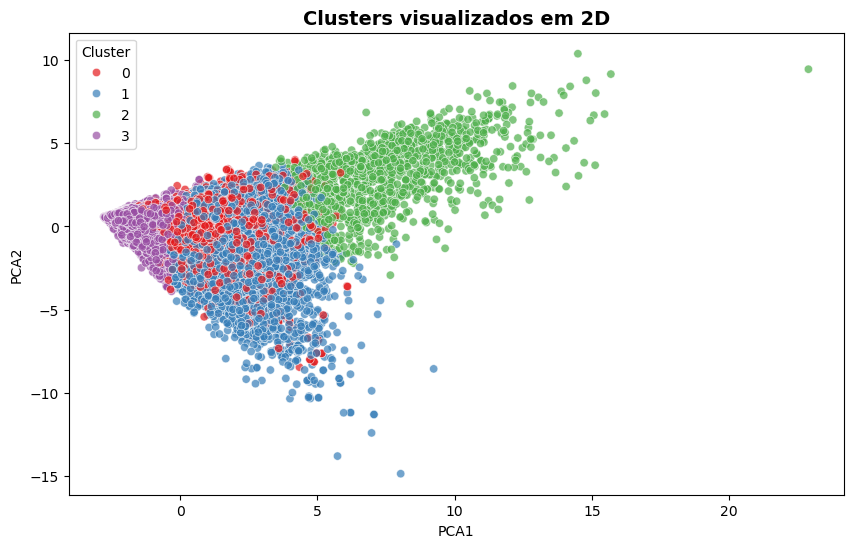

In [44]:
# PCA 2 componentes p/ visualização

pca_vis = PCA(n_components=2)
pca_result = pca_vis.fit_transform(df_scaled)

df_cluster['PCA1'] = pca_result[:, 0]
df_cluster['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='Set1',
    data=df_cluster,
    alpha=0.7
)
plt.title('Clusters visualizados em 2D', fontsize=14, fontweight='bold')
plt.legend(title='Cluster')
plt.show()



Médias por cluster:
          qtd_discentes  postura_profissional_media  \
Cluster                                              
0             0.119741                    0.941358   
1             0.080655                    0.915615   
2             0.315994                    0.925122   
3             0.036503                    0.974941   

         atuacao_profissional_media  autoavaliacao_aluno_media  \
Cluster                                                          
0                          0.906868                   0.809227   
1                          0.856697                   0.754958   
2                          0.867449                   0.713905   
3                          0.953002                   0.909544   

         media_final_geral  qtd_trancado  qtd_aprovado  qtd_aprovado_por_nota  \
Cluster                                                                         
0                 0.839626      0.038496      0.108121               0.017611   
1            

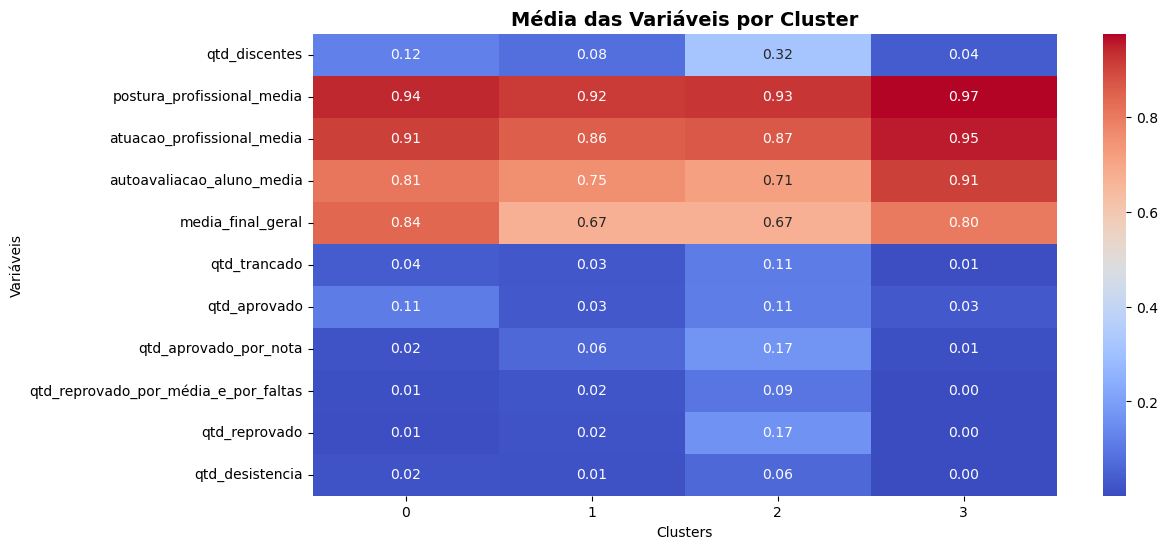

In [45]:
# estatísticas dos clusters

cluster_summary = df_cluster.groupby('Cluster')[features_clustering].mean()
print("\nMédias por cluster:\n", cluster_summary)

# mapadecalor das médias
plt.figure(figsize=(12,6))
sns.heatmap(cluster_summary.T, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Média das Variáveis por Cluster", fontsize=14, fontweight="bold")
plt.ylabel("Variáveis")
plt.xlabel("Clusters")
plt.show()
